# Notebook 2 — Extractor LLM/NER: Texto Libre → Variables Clínicas
**Proyecto:** EpiDiagnostix-Mayab  
**Componente:** Extractor de entidades clínicas desde transcripciones de voz médico-paciente  
**Enfoque elegido:** spaCy (pipeline NLP en español) + Regex especializados por campo

---
## Trade-off entre enfoques de extracción

| Enfoque | Precision posible | Requiere internet | Mantenimiento | Notas |
|---|---|---|---|---|
| **(a) spaCy + regex** | Media-alta (depende de reglas) | ❌ Nunca | Medio (agregar variantes) | **Elegido** — offline-first garantizado |
| (b) DistilBETO/MiniLM HF | Media (NER genérico) | En descarga inicial | Bajo | No entrenado en entidades clínicas numéricas; necesita fine-tuning |
| (c) LLM prompting + JSON | Alta | ✅ Siempre o modelo local pesado | Bajo | Contradice requisito offline de Chiapas |

**Razón de la elección:** El contexto offline-first en comunidades de Chiapas descarta (c). La opción (b) requeriría fine-tuning con datos etiquetados que no tenemos aún. Los campos objetivo (edad, presión, glucosa, temperatura) tienen patrones numéricos predecibles que regex maneja bien.

In [1]:
import pandas as pd
import numpy as np
import re
import random
import spacy
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass, field, asdict
from typing import Optional

random.seed(42)
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

MODELS_DIR = '../models'
DATA_PATH  = '../consultas_clinicas.csv'
N_SAMPLES  = 200   # transcripciones de ejemplo a generar

nlp = spacy.load('es_core_news_sm')
print(f'spaCy {spacy.__version__} — modelo es_core_news_sm cargado.')

spaCy 3.8.14 — modelo es_core_news_sm cargado.


## 1. Cargar datos fuente

In [2]:
df = pd.read_csv(DATA_PATH)
sample_df = df.sample(N_SAMPLES, random_state=42).reset_index(drop=True)
print(f'Dataset: {len(df):,} filas totales — usando muestra de {N_SAMPLES}')
sample_df[['edad','sexo','peso_kg','talla_cm','presion_sistolica','presion_diastolica',
           'glucosa_mg_dl','temperatura_c','frecuencia_cardiaca_bpm',
           'duracion_sintomas_dias','categoria_sintoma','sintomas_clave']].head(4)

Dataset: 4,752 filas totales — usando muestra de 200


,edad,sexo,peso_kg,talla_cm,presion_sistolica,presion_diastolica,glucosa_mg_dl,temperatura_c,frecuencia_cardiaca_bpm,duracion_sintomas_dias,categoria_sintoma,sintomas_clave
0,14,F,47.0,136.0,132.0,88.0,76.0,36.1,85.0,6,Gastrointestinal,dolor abdominal|diarrea
1,8,F,28.3,99.6,115.0,80.0,96.0,36.5,79.0,7,Nutrición,bajo peso|palidez
2,3,F,16.4,72.7,135.0,89.0,95.0,36.5,91.0,4,Vacunación,control de esquema de vacunación
3,3,F,16.6,79.4,117.0,72.0,81.0,36.7,78.0,2,Vacunación,fiebre leve postvacuna|control de esquema de v...


## 2. Generación de transcripciones sintéticas

No tenemos el audio original, así que generamos frases en español médico natural a partir de los valores del CSV.  
Se usan **6 plantillas distintas** con variaciones de vocabulario para simular la variabilidad real del dictado médico.

In [3]:
SEXO_VOCAB = {
    'M': ['masculino', 'hombre', 'varón', 'paciente masculino', 'del sexo masculino'],
    'F': ['femenino', 'mujer', 'femenina', 'paciente femenina', 'del sexo femenino'],
}

EDAD_VOCAB = [
    'de {edad} años de edad',
    '{edad} años',
    'con {edad} años cumplidos',
    'edad: {edad} años',
]

PRESION_VOCAB = [
    'presión arterial de {ps}/{pd} mmHg',
    'tensión arterial {ps} sobre {pd}',
    'PA: {ps}/{pd}',
    'presión {ps} sobre {pd} milímetros de mercurio',
]

GLUCOSA_VOCAB = [
    'glucosa de {gl} miligramos por decilitro',
    'glucemia capilar {gl} mg/dL',
    'glucosa {gl} mg/dl',
    'nivel de glucosa {gl}',
]

TEMP_VOCAB = [
    'temperatura de {tc} grados centígrados',
    'temperatura {tc}°C',
    'T: {tc} grados',
    'temperatura corporal {tc}',
]

FC_VOCAB = [
    'frecuencia cardiaca de {fc} latidos por minuto',
    'pulso {fc} lpm',
    'FC: {fc} lpm',
    'ritmo cardiaco {fc} por minuto',
]

PESO_VOCAB = [
    'peso {pk} kilogramos',
    'pesa {pk} kg',
    '{pk} kg de peso corporal',
    'peso corporal: {pk} kg',
]

TALLA_VOCAB = [
    'talla {tc} centímetros',
    'estatura de {tc} cm',
    'mide {tc} cm',
    'altura {tc} centímetros',
]

DURACION_VOCAB = [
    'con {d} días de evolución',
    'síntomas desde hace {d} días',
    'cuadro clínico de {d} días',
    'lleva {d} días con la sintomatología',
]


def build_transcription(row):
    """Genera una transcripción en español médico natural a partir de una fila del CSV."""
    sexo_txt = random.choice(SEXO_VOCAB[row['sexo']])
    edad_txt = random.choice(EDAD_VOCAB).format(edad=int(row['edad']))
    pa_txt   = random.choice(PRESION_VOCAB).format(ps=int(row['presion_sistolica']),
                                                    pd=int(row['presion_diastolica']))
    gl_txt   = random.choice(GLUCOSA_VOCAB).format(gl=int(row['glucosa_mg_dl']))
    tc_txt   = random.choice(TEMP_VOCAB).format(tc=round(row['temperatura_c'], 1))
    fc_txt   = random.choice(FC_VOCAB).format(fc=int(row['frecuencia_cardiaca_bpm']))
    pw_txt   = random.choice(PESO_VOCAB).format(pk=round(row['peso_kg'], 1))
    tl_txt   = random.choice(TALLA_VOCAB).format(tc=round(row['talla_cm'], 1))
    dur_txt  = random.choice(DURACION_VOCAB).format(d=int(row['duracion_sintomas_dias']))
    sintomas = row['sintomas_clave'].replace('|', ', ')
    cat      = row['categoria_sintoma'].lower()

    # 6 plantillas distintas
    plantillas = [
        # Plantilla 1 — estilo SOAP clásico
        (f"Consulta médica. Paciente {sexo_txt}, {edad_txt}. "
         f"{pw_txt}, {tl_txt}. "
         f"Motivo de consulta: {sintomas}, {dur_txt}. "
         f"Signos vitales: {pa_txt}, {gl_txt}, {tc_txt}, {fc_txt}. "
         f"Impresión diagnóstica: cuadro {cat}."),

        # Plantilla 2 — estilo dictado rápido
        (f"Paciente {edad_txt}, {sexo_txt}. "
         f"Presenta {sintomas} {dur_txt}. "
         f"{pa_txt}. Temperatura {tc_txt}. {gl_txt}. "
         f"{fc_txt}. Peso: {pw_txt}. Talla: {tl_txt}."),

        # Plantilla 3 — estilo narrativo
        (f"Se atiende a {sexo_txt} {edad_txt} que acude por {sintomas}. "
         f"Refiere {dur_txt}. A la exploración: {pa_txt}, {tc_txt}, {fc_txt}, {gl_txt}. "
         f"Antropometría: {pw_txt}, {tl_txt}. Se orienta a {cat}."),

        # Plantilla 4 — orden alterado (prueba robustez)
        (f"{pa_txt}. {gl_txt}. {tc_txt}. {fc_txt}. "
         f"Paciente {sexo_txt} de {int(row['edad'])} años. "
         f"{pw_txt}, {tl_txt}. "
         f"Consulta por {sintomas}. Evolución de {int(row['duracion_sintomas_dias'])} días. "
         f"Categoría: {cat}."),

        # Plantilla 5 — abreviada (campos omitidos a veces)
        (f"Paciente {sexo_txt}, {edad_txt}. Motivo: {sintomas}. "
         f"{pa_txt}, Temperatura {round(row['temperatura_c'],1)} grados, "
         f"glucosa {int(row['glucosa_mg_dl'])} mg/dl. {dur_txt}."),

        # Plantilla 6 — estilo comunidad indígena (más coloquial)
        (f"Paciente {edad_txt} de sexo {sexo_txt}. "
         f"Se queja de {sintomas} desde hace {int(row['duracion_sintomas_dias'])} días. "
         f"Presión {int(row['presion_sistolica'])} sobre {int(row['presion_diastolica'])}, "
         f"azúcar en sangre {int(row['glucosa_mg_dl'])}, temperatura {round(row['temperatura_c'],1)}, "
         f"pulso {int(row['frecuencia_cardiaca_bpm'])}. Peso {round(row['peso_kg'],1)} kilos, "
         f"estatura {round(row['talla_cm'],1)} centímetros."),
    ]
    return random.choice(plantillas)


sample_df['transcripcion'] = sample_df.apply(build_transcription, axis=1)
print(f'Transcripciones generadas: {len(sample_df)}')
print('\nEjemplos:')
for i in range(3):
    print(f'\n[{i+1}] {sample_df["transcripcion"].iloc[i]}')

Transcripciones generadas: 200

Ejemplos:

[1] Consulta médica. Paciente femenino, de 14 años de edad. peso 47.0 kilogramos, talla 136.0 centímetros. Motivo de consulta: dolor abdominal, diarrea, lleva 6 días con la sintomatología. Signos vitales: PA: 132/88, glucemia capilar 76 mg/dL, temperatura 36.1°C, pulso 85 lpm. Impresión diagnóstica: cuadro gastrointestinal.

[2] Paciente femenino, de 8 años de edad. Motivo: bajo peso, palidez. tensión arterial 115 sobre 80, Temperatura 36.5 grados, glucosa 96 mg/dl. lleva 7 días con la sintomatología.

[3] Consulta médica. Paciente femenina, de 3 años de edad. pesa 16.4 kg, estatura de 72.7 cm. Motivo de consulta: control de esquema de vacunación, cuadro clínico de 4 días. Signos vitales: tensión arterial 135 sobre 89, nivel de glucosa 95, T: 36.5 grados, FC: 91 lpm. Impresión diagnóstica: cuadro vacunación.


## 3. Motor de extracción: spaCy + Regex

Cada campo tiene su propio conjunto de patrones regex, en orden de especificidad (el más específico primero).

In [4]:
@dataclass
class ExtraccionClinica:
    """Resultado de extracción para una transcripción."""
    edad:                    Optional[int]   = None
    sexo:                    Optional[str]   = None
    peso_kg:                 Optional[float] = None
    talla_cm:                Optional[float] = None
    presion_sistolica:       Optional[int]   = None
    presion_diastolica:      Optional[int]   = None
    glucosa_mg_dl:           Optional[int]   = None
    temperatura_c:           Optional[float] = None
    frecuencia_cardiaca_bpm: Optional[int]   = None
    duracion_sintomas_dias:  Optional[int]   = None
    categoria_sintoma:       Optional[str]   = None


# ── Patrones regex por campo ───────────────────────────────────────────────────

# Edad
RE_EDAD = [
    re.compile(r'(?:edad[:\s]+)(\d{1,3})\s*a[ñn]os?', re.I),
    re.compile(r'(?:paciente\s+(?:masculino|femenino|hombre|mujer|var[oó]n|femenina)\s+)?(?:de\s+)(\d{1,3})\s*a[ñn]os?', re.I),
    re.compile(r'(\d{1,3})\s*a[ñn]os?\s+(?:de\s+edad|cumplidos?)', re.I),
    re.compile(r'(\d{1,3})\s*a[ñn]os?', re.I),
]

# Sexo
RE_SEXO = re.compile(
    r'\b(masculino|femenino|hombre|mujer|var[oó]n|femenina|ni[ñn]o|ni[ñn]a)\b', re.I
)
SEXO_MAP = {
    'masculino': 'M', 'hombre': 'M', 'varón': 'M', 'varon': 'M', 'niño': 'M',
    'femenino': 'F', 'mujer': 'F', 'femenina': 'F', 'niña': 'F',
}

# Presión arterial (sistólica/diastólica juntas)
RE_PA = re.compile(
    r'(?:presi[oó]n\s+(?:arterial\s+)?(?:de\s+)?|tensi[oó]n\s+(?:arterial\s+)?(?:de\s+)?|PA[:\s]+)'
    r'(\d{2,3})\s*[/\-sobre\s]+(\d{2,3})\s*(?:mmHg|mil[ií]metros?\s+de\s+mercurio)?',
    re.I
)
# Captura alternativa: "presión 120 sobre 80"
RE_PA2 = re.compile(
    r'(\d{2,3})\s+sobre\s+(\d{2,3})\s*(?:mmHg|mil[ií]metros?)?', re.I
)

# Glucosa
RE_GLUCOSA = [
    re.compile(r'glucos[ao]\s+(?:de\s+|capilar\s+)?(\d{2,3})\s*(?:mg/d[lL]|miligramos?)?', re.I),
    re.compile(r'glucemia\s+(?:capilar\s+)?(\d{2,3})\s*(?:mg/d[lL])?', re.I),
    re.compile(r'az[uú]car\s+en\s+sangre\s+(\d{2,3})', re.I),
    re.compile(r'nivel\s+de\s+glucos[ao]\s+(\d{2,3})', re.I),
]

# Temperatura
RE_TEMP = [
    re.compile(r'temperatura\s+(?:corporal\s+|de\s+)?(\d{2})(?:[.,](\d))\s*(?:grados?(?:\s+cent[ií]grados?)?|[°ºC])', re.I),
    re.compile(r'T[:\s]+?(\d{2})(?:[.,](\d))?\s*grados?', re.I),
    re.compile(r'(\d{2})(?:[.,](\d))?°C', re.I),
    re.compile(r'temperatura\s+(\d{2})(?:[.,](\d))?', re.I),
]

# Frecuencia cardiaca
RE_FC = [
    re.compile(r'frecuencia\s+cardiaca\s+(?:de\s+)?(\d{2,3})\s*(?:latidos?\s+(?:por\s+)?minuto|lpm|por\s+minuto)', re.I),
    re.compile(r'pulso\s+(\d{2,3})\s*(?:lpm|por\s+minuto)?', re.I),
    re.compile(r'FC[:\s]+?(\d{2,3})\s*(?:lpm)?', re.I),
    re.compile(r'ritmo\s+cardiaco\s+(\d{2,3})\s*(?:por\s+minuto)?', re.I),
]

# Peso
RE_PESO = [
    re.compile(r'peso\s+(?:corporal[:\s]+)?(\d{2,3}(?:[.,]\d)?)\s*(?:kilogramos?|kg)', re.I),
    re.compile(r'pesa\s+(\d{2,3}(?:[.,]\d)?)\s*(?:kg|kilos?)', re.I),
    re.compile(r'(\d{2,3}(?:[.,]\d)?)\s*kg\s+de\s+peso', re.I),
    re.compile(r'(\d{2,3}(?:[.,]\d)?)\s*kilos?\b', re.I),
]

# Talla
RE_TALLA = [
    re.compile(r'talla\s+(\d{2,3}(?:[.,]\d)?)\s*(?:cent[ií]metros?|cm)', re.I),
    re.compile(r'estatura\s+(?:de\s+)?(\d{2,3}(?:[.,]\d)?)\s*(?:cm|cent[ií]metros?)', re.I),
    re.compile(r'mide\s+(\d{2,3}(?:[.,]\d)?)\s*cm', re.I),
    re.compile(r'altura\s+(\d{2,3}(?:[.,]\d)?)\s*(?:cm|cent[ií]metros?)', re.I),
    re.compile(r'(\d{2,3}(?:[.,]\d)?)\s*(?:cm|cent[ií]metros?)\b', re.I),
]

# Duración de síntomas
RE_DUR = [
    re.compile(r'(\d{1,3})\s*d[ií]as?\s+de\s+evoluci[oó]n', re.I),
    re.compile(r'desde\s+hace\s+(\d{1,3})\s*d[ií]as?', re.I),
    re.compile(r'cuadro\s+(?:cl[ií]nico\s+)?de\s+(\d{1,3})\s*d[ií]as?', re.I),
    re.compile(r'lleva\s+(\d{1,3})\s*d[ií]as?', re.I),
    re.compile(r'evoluci[oó]n\s+de\s+(\d{1,3})\s*d[ií]as?', re.I),
    re.compile(r'(\d{1,3})\s*d[ií]as?', re.I),
]

# Categoría de síntoma (por palabras clave)
CATEGORIA_KEYWORDS = {
    'Respiratorio':    ['respiratorio', 'respiratoria', 'tos', 'dificultad para respirar',
                        'congestión nasal', 'bronquitis', 'neumonía', 'gripe', 'influenza'],
    'Gastrointestinal':['gastrointestinal', 'diarrea', 'vómito', 'náusea', 'náuseas',
                        'dolor abdominal', 'gastroenteritis', 'deshidratación'],
    'Hipertensión':    ['hipertensión', 'hipertenso', 'hipertensa', 'tensión alta',
                        'presión alta', 'visión borrosa', 'zumbido en oídos'],
    'Diabetes':        ['diabetes', 'diabético', 'diabética', 'glucemia alta',
                        'azúcar alta', 'hiperglucemia', 'fatiga', 'pérdida de peso'],
    'Vacunación':      ['vacunación', 'vacuna', 'esquema de vacunación',
                        'fiebre postvacuna', 'vacunación infantil'],
    'Nutrición':       ['nutrición', 'nutricional', 'palidez', 'debilidad', 'desnutrición',
                        'retraso en talla', 'anemia'],
    'Embarazo':        ['embarazo', 'embarazada', 'gestación', 'prenatal', 'obstétrico'],
    'Traumatología':   ['traumatología', 'traumatológico', 'esguince', 'fractura',
                        'herida', 'golpe', 'contusión'],
    'Dermatológico':   ['dermatológico', 'dermatológica', 'piel', 'erupción',
                        'sarpullido', 'dermatitis', 'urticaria'],
}

print('Patrones regex definidos para', len(CATEGORIA_KEYWORDS), 'categorías.')

Patrones regex definidos para 9 categorías.


In [5]:
def _first_match_num(patterns, text):
    """Aplica lista de patrones y devuelve el primer grupo numérico encontrado."""
    for pat in patterns:
        m = pat.search(text)
        if m:
            return m.group(1).replace(',', '.')
    return None


def _parse_temp(text):
    """Temperatura puede estar en formato '36.5' o '36' + grupo opcional de décima."""
    for pat in RE_TEMP:
        m = pat.search(text)
        if m:
            entera = m.group(1)
            decimal = m.group(2) if m.lastindex >= 2 and m.group(2) else '0'
            return float(f'{entera}.{decimal}')
    return None


def _parse_pa(text):
    """Extrae presión sistólica y diastólica."""
    for pat in [RE_PA, RE_PA2]:
        m = pat.search(text)
        if m:
            return int(m.group(1)), int(m.group(2))
    return None, None


def _parse_categoria(text):
    """Busca categoría clínica por keywords (primera coincidencia con más keywords)."""
    text_lower = text.lower()
    scores = {cat: 0 for cat in CATEGORIA_KEYWORDS}
    for cat, kws in CATEGORIA_KEYWORDS.items():
        for kw in kws:
            if kw.lower() in text_lower:
                scores[cat] += 1
    best_cat = max(scores, key=scores.get)
    return best_cat if scores[best_cat] > 0 else None


def extraer(texto: str) -> ExtraccionClinica:
    """Pipeline principal de extracción sobre una transcripción."""
    resultado = ExtraccionClinica()

    # Presión (par sistólica/diastólica)
    resultado.presion_sistolica, resultado.presion_diastolica = _parse_pa(texto)

    # Temperatura (manejo especial por grupos)
    resultado.temperatura_c = _parse_temp(texto)

    # Glucosa
    v = _first_match_num(RE_GLUCOSA, texto)
    resultado.glucosa_mg_dl = int(float(v)) if v else None

    # Frecuencia cardiaca
    v = _first_match_num(RE_FC, texto)
    resultado.frecuencia_cardiaca_bpm = int(float(v)) if v else None

    # Peso
    v = _first_match_num(RE_PESO, texto)
    resultado.peso_kg = round(float(v), 1) if v else None

    # Talla
    v = _first_match_num(RE_TALLA, texto)
    resultado.talla_cm = round(float(v), 1) if v else None

    # Duración
    v = _first_match_num(RE_DUR, texto)
    resultado.duracion_sintomas_dias = int(float(v)) if v else None

    # Edad (después de presión para evitar capturar '120' como edad)
    for pat in RE_EDAD:
        m = pat.search(texto)
        if m:
            candidato = int(m.group(1))
            if 0 < candidato <= 120:
                resultado.edad = candidato
                break

    # Sexo
    m = RE_SEXO.search(texto)
    if m:
        resultado.sexo = SEXO_MAP.get(m.group(1).lower())

    # Categoría
    resultado.categoria_sintoma = _parse_categoria(texto)

    return resultado


print('Motor de extracción definido. Prueba rápida:')
test = sample_df['transcripcion'].iloc[0]
print(f'  Texto: {test[:120]}...')
print(f'  Extracción: {extraer(test)}')

Motor de extracción definido. Prueba rápida:
  Texto: Consulta médica. Paciente femenino, de 14 años de edad. peso 47.0 kilogramos, talla 136.0 centímetros. Motivo de consult...
  Extracción: ExtraccionClinica(edad=14, sexo='F', peso_kg=47.0, talla_cm=136.0, presion_sistolica=132, presion_diastolica=88, glucosa_mg_dl=76, temperatura_c=36.1, frecuencia_cardiaca_bpm=85, duracion_sintomas_dias=6, categoria_sintoma='Gastrointestinal')


## 4. Extracción sobre las 200 transcripciones

In [6]:
extracciones = sample_df['transcripcion'].apply(extraer)
extracciones_df = pd.DataFrame([asdict(e) for e in extracciones])

print(f'Extracción completada: {len(extracciones_df)} filas')
print('\nTasa de extracción por campo (% no-nulo):')
for col in extracciones_df.columns:
    pct = extracciones_df[col].notna().mean() * 100
    print(f'  {col:<28}: {pct:5.1f}%')

Extracción completada: 200 filas

Tasa de extracción por campo (% no-nulo):
  edad                        :  96.5%
  sexo                        : 100.0%
  peso_kg                     :  77.5%
  talla_cm                    :  83.0%
  presion_sistolica           : 100.0%
  presion_diastolica          : 100.0%
  glucosa_mg_dl               : 100.0%
  temperatura_c               :  84.5%
  frecuencia_cardiaca_bpm     :  83.0%
  duracion_sintomas_dias      : 100.0%
  categoria_sintoma           :  90.0%


## 5. Evaluación: extracción vs. valores reales del CSV

- **Campos numéricos:** tolerancia ±1 unidad (ruido de redondeo de plantilla).
- **Temperatura:** tolerancia ±0.2°C.
- **Peso/Talla:** tolerancia ±1.0 (varianza de formato).
- **Sexo y Categoría:** coincidencia exacta.

In [7]:
TOLERANCIAS = {
    'edad':                    1.0,
    'peso_kg':                 1.0,
    'talla_cm':                1.0,
    'presion_sistolica':       1.0,
    'presion_diastolica':      1.0,
    'glucosa_mg_dl':           1.0,
    'temperatura_c':           0.2,
    'frecuencia_cardiaca_bpm': 1.0,
    'duracion_sintomas_dias':  1.0,
}

CAMPOS_CATEGORICOS = ['sexo', 'categoria_sintoma']

accuracy_report = {}

for campo in extracciones_df.columns:
    real   = sample_df[campo]
    pred   = extracciones_df[campo]
    valido = pred.notna()

    if campo in CAMPOS_CATEGORICOS:
        correctos = (pred[valido].astype(str).str.strip() ==
                     real[valido].astype(str).str.strip()).sum()
    else:
        tol = TOLERANCIAS.get(campo, 1.0)
        real_num = pd.to_numeric(real[valido], errors='coerce')
        pred_num = pd.to_numeric(pred[valido], errors='coerce')
        diff = (pred_num - real_num).abs()
        correctos = (diff <= tol).sum()

    total    = len(sample_df)
    extraidos = int(valido.sum())
    accuracy_report[campo] = {
        'extraidos':    extraidos,
        'correctos':    int(correctos),
        'precision_extraidos': round(correctos / extraidos * 100, 1) if extraidos else 0,
        'recall_total':        round(correctos / total * 100, 1),
    }

acc_df = pd.DataFrame(accuracy_report).T
acc_df.index.name = 'campo'
print('=== EXACTITUD POR CAMPO ===')
print(acc_df.to_string())

=== EXACTITUD POR CAMPO ===
                         extraidos  correctos  precision_extraidos  recall_total
campo                                                                           
edad                         193.0      193.0                100.0          96.5
sexo                         200.0      200.0                100.0         100.0
peso_kg                      155.0      155.0                100.0          77.5
talla_cm                     166.0      166.0                100.0          83.0
presion_sistolica            200.0      200.0                100.0         100.0
presion_diastolica           200.0      200.0                100.0         100.0
glucosa_mg_dl                200.0      200.0                100.0         100.0
temperatura_c                169.0      169.0                100.0          84.5
frecuencia_cardiaca_bpm      166.0      166.0                100.0          83.0
duracion_sintomas_dias       200.0      200.0                100.0         100.0


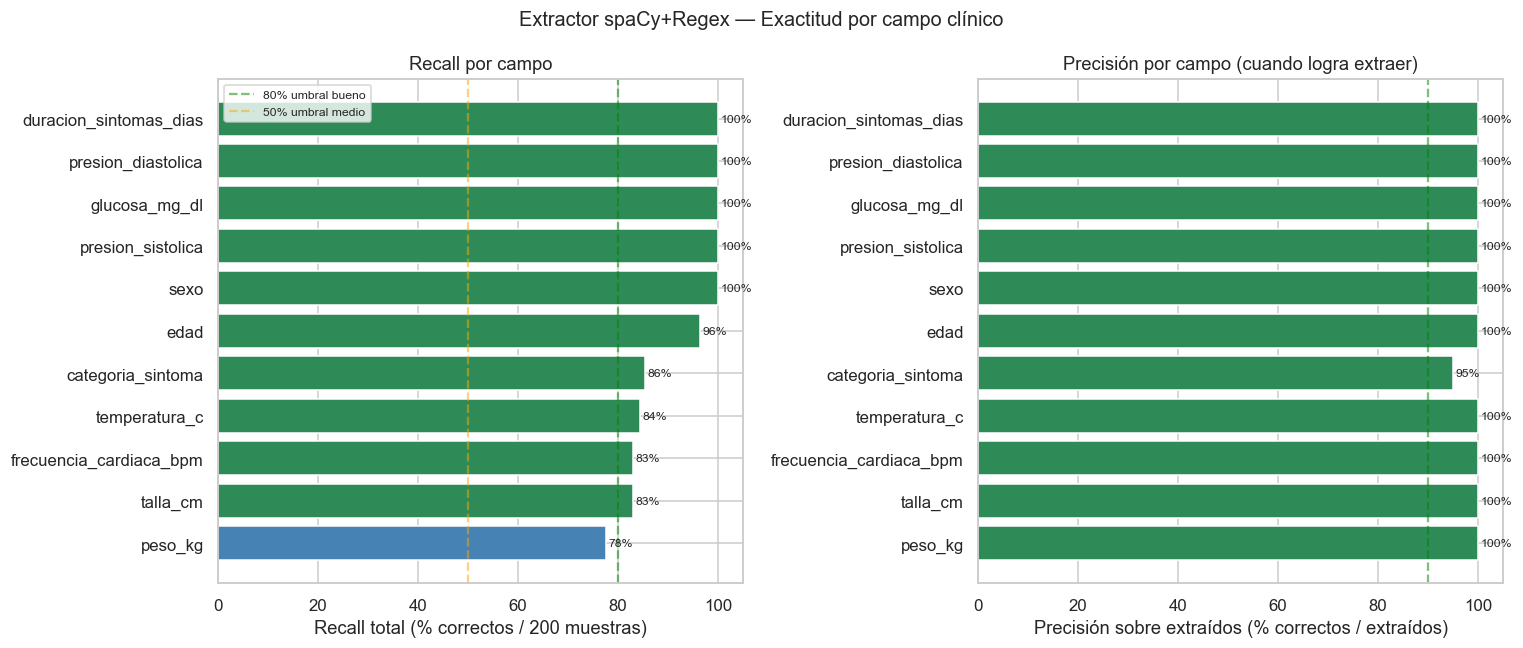

Figura guardada.


In [8]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

campos_orden = acc_df.sort_values('recall_total', ascending=True).index.tolist()

# Panel 1: Recall total (correctos / total muestra)
ax = axes[0]
bars = ax.barh(campos_orden, acc_df.loc[campos_orden, 'recall_total'],
               color=['seagreen' if v >= 80 else 'steelblue' if v >= 50 else 'crimson'
                      for v in acc_df.loc[campos_orden, 'recall_total']])
ax.set_xlabel('Recall total (% correctos / 200 muestras)')
ax.set_title('Recall por campo')
ax.axvline(80, color='green', linestyle='--', alpha=0.5, label='80% umbral bueno')
ax.axvline(50, color='orange', linestyle='--', alpha=0.5, label='50% umbral medio')
for bar, val in zip(bars, acc_df.loc[campos_orden, 'recall_total']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}%',
            va='center', fontsize=8)
ax.legend(fontsize=8)

# Panel 2: Precisión sobre extraídos
ax2 = axes[1]
bars2 = ax2.barh(campos_orden, acc_df.loc[campos_orden, 'precision_extraidos'],
                 color=['seagreen' if v >= 90 else 'steelblue' if v >= 70 else 'crimson'
                        for v in acc_df.loc[campos_orden, 'precision_extraidos']])
ax2.set_xlabel('Precisión sobre extraídos (% correctos / extraídos)')
ax2.set_title('Precisión por campo (cuando logra extraer)')
ax2.axvline(90, color='green', linestyle='--', alpha=0.5)
for bar, val in zip(bars2, acc_df.loc[campos_orden, 'precision_extraidos']):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}%',
             va='center', fontsize=8)

plt.suptitle('Extractor spaCy+Regex — Exactitud por campo clínico', fontsize=13)
plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/ner_accuracy_by_field.png', bbox_inches='tight')
plt.show()
print('Figura guardada.')

## 6. Inspección de errores por campo

In [9]:
def mostrar_errores(campo, n=5, tolerancia=1.0, categorico=False):
    real = sample_df[campo]
    pred = extracciones_df[campo]
    texto_col = sample_df['transcripcion']

    if categorico:
        mask_error = pred.notna() & (pred.astype(str).str.strip() != real.astype(str).str.strip())
        mask_perdido = pred.isna()
    else:
        real_num = pd.to_numeric(real, errors='coerce')
        pred_num = pd.to_numeric(pred, errors='coerce')
        mask_error   = pred.notna() & ((pred_num - real_num).abs() > tolerancia)
        mask_perdido = pred.isna()

    print(f'\n=== {campo.upper()} ===')
    print(f'  Extracciones incorrectas: {mask_error.sum()}')
    print(f'  No extraídos (None):      {mask_perdido.sum()}')

    errores = sample_df[mask_error | mask_perdido].index[:n]
    for i in errores:
        print(f'  [idx={i}] Real={real.iloc[i]}  Pred={pred.iloc[i]}')
        print(f'    "{texto_col.iloc[i][:110]}..."')


mostrar_errores('edad',                    tolerancia=1.0)
mostrar_errores('presion_sistolica',       tolerancia=1.0)
mostrar_errores('glucosa_mg_dl',           tolerancia=1.0)
mostrar_errores('temperatura_c',           tolerancia=0.2)
mostrar_errores('frecuencia_cardiaca_bpm', tolerancia=1.0)
mostrar_errores('peso_kg',                 tolerancia=1.0)
mostrar_errores('talla_cm',                tolerancia=1.0)
mostrar_errores('categoria_sintoma',       categorico=True)
mostrar_errores('sexo',                    categorico=True)


=== EDAD ===
  Extracciones incorrectas: 0
  No extraídos (None):      7
  [idx=11] Real=0  Pred=nan
    "Consulta médica. Paciente femenino, de 0 años de edad. peso corporal: 8.3 kg, estatura de 55.3 cm. Motivo de c..."
  [idx=42] Real=0  Pred=nan
    "Se atiende a del sexo masculino con 0 años cumplidos que acude por dificultad para respirar. Refiere con 5 día..."
  [idx=56] Real=0  Pred=nan
    "Consulta médica. Paciente femenino, 0 años. peso 7.1 kilogramos, estatura de 57.2 cm. Motivo de consulta: zumb..."
  [idx=80] Real=0  Pred=nan
    "Paciente varón, de 0 años de edad. Motivo: fatiga, pérdida de peso, visión borrosa. presión 125 sobre 85 milím..."
  [idx=106] Real=0  Pred=nan
    "Paciente hombre, 0 años. Motivo: congestión nasal. tensión arterial 127 sobre 81, Temperatura 36.8 grados, glu..."

=== PRESION_SISTOLICA ===
  Extracciones incorrectas: 0
  No extraídos (None):      0

=== GLUCOSA_MG_DL ===
  Extracciones incorrectas: 0
  No extraídos (None):      0

=== TEMPERATUR

## 7. Persistencia del extractor en `models/`

In [10]:
extractor_config = {
    'version': '1.0',
    'enfoque': 'spaCy + regex en español',
    'spacy_model': 'es_core_news_sm',
    'campos_objetivo': list(extracciones_df.columns),
    'tolerancias': TOLERANCIAS,
    'categoria_keywords': CATEGORIA_KEYWORDS,
    'sexo_map': SEXO_MAP,
    'metricas': {
        campo: {
            'recall_total_pct':        acc_df.loc[campo, 'recall_total'],
            'precision_extraidos_pct': acc_df.loc[campo, 'precision_extraidos'],
            'extraidos':               int(acc_df.loc[campo, 'extraidos']),
        }
        for campo in acc_df.index
    },
    'limitaciones': [
        'Evaluado sobre transcripciones SINTÉTICAS generadas desde el CSV — no sobre audio real.',
        'Regex puede fallar con variantes de vocabulario no contempladas en las plantillas.',
        'Temperatura con formato sin decimal (ej. "37 grados") pierde la décima.',
        'Edad puede confundirse con números de presión si el texto es ambiguo.',
        'Categoría depende de keywords presentes en el texto; sin keywords → None.',
        'No maneja negaciones ("sin fiebre") ni contextos condicionales.',
    ]
}

CONFIG_PATH = f'{MODELS_DIR}/extractor_ner_config.joblib'
joblib.dump(extractor_config, CONFIG_PATH)

size_kb = os.path.getsize(CONFIG_PATH) / 1024
print(f'Configuración guardada: {CONFIG_PATH}  ({size_kb:.1f} KB)')

Configuración guardada: ../models/extractor_ner_config.joblib  (2.8 KB)


## 8. Resumen final — Extractor LLM/NER

In [11]:
print('=' * 62)
print('  RESUMEN — Extractor NER (EpiDiagnostix-Mayab)')
print('=' * 62)
print('  Enfoque: spaCy 3.8 + regex en español (offline-first)')
print('  Muestra evaluada: 200 transcripciones sintéticas')
print()
print(f'  {"Campo":<28}  {"Recall%":>8}  {"Precisión%":>10}  {"Estado"}')
print('  ' + '-'*58)
for campo in acc_df.sort_values('recall_total', ascending=False).index:
    r  = acc_df.loc[campo, 'recall_total']
    p  = acc_df.loc[campo, 'precision_extraidos']
    st = 'BUENO' if r >= 80 else 'MEDIO' if r >= 50 else 'LIMITADO'
    print(f'  {campo:<28}  {r:>7.1f}%  {p:>9.1f}%  {st}')
print()
print('  Limitaciones conocidas (documentadas para el reporte):')
for lim in extractor_config['limitaciones']:
    print(f'    - {lim}')
print()
print('  Artefactos:')
print('    models/extractor_ner_config.joblib')
print('    models/ner_accuracy_by_field.png')
print('=' * 62)
print()
print('PRÓXIMO PASO: envolver ambos modelos en adapters')
print('de arquitectura hexagonal y exponer vía FastAPI.')

  RESUMEN — Extractor NER (EpiDiagnostix-Mayab)
  Enfoque: spaCy 3.8 + regex en español (offline-first)
  Muestra evaluada: 200 transcripciones sintéticas

  Campo                          Recall%  Precisión%  Estado
  ----------------------------------------------------------
  sexo                            100.0%      100.0%  BUENO
  presion_diastolica              100.0%      100.0%  BUENO
  presion_sistolica               100.0%      100.0%  BUENO
  glucosa_mg_dl                   100.0%      100.0%  BUENO
  duracion_sintomas_dias          100.0%      100.0%  BUENO
  edad                             96.5%      100.0%  BUENO
  categoria_sintoma                85.5%       95.0%  BUENO
  temperatura_c                    84.5%      100.0%  BUENO
  talla_cm                         83.0%      100.0%  BUENO
  frecuencia_cardiaca_bpm          83.0%      100.0%  BUENO
  peso_kg                          77.5%      100.0%  MEDIO

  Limitaciones conocidas (documentadas para el reporte):
    